## Sample Project
##### PBMCs from ACD-A Treated Blood Collection Tubes Isolated via SepMate-Ficoll Gradient (3' v3.1 Chemistry)

**Dataset Overview**
Donor Information: Healthy female. 

Isolation protocol: CG000392.RevA: Isolation of Leukocytes, Bone Marrow and Peripheral Blood Mononuclear Cells for Single Cell RNA Sequencing.

- Sequencing instrument: Illumina NovaSeq 6000
- Sequencing depth: 23,763 - number of reads per cell
- Cells detected: 5,108
- Median genes per cell: 1,364 - Those 4,400 unique molecules came from 1,364 different genes.
- Median UMIs per cell: 4,373 - Out of those 24,000 looks, it only found ~4,400 unique molecules.

Roughly 121 million total reads ($23,763 \times 5,108$)

Some variables (=genes) appear more than once which can lead to errors or unintended behavior for downstream analysis tasks. We execute the proposed function `var_names_make_unique()` which makes the variable name unique by appending a number string to each duplicate index element: ‘1’, ‘2’, etc.

In [1]:
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

adata = sc.read_10x_mtx("filtered_feature_bc_matrix", var_names="gene_symbols", cache=False)
# Ensures no duplicate gene names
adata.var_names_make_unique()
print(f"Starting cells: {adata.n_obs}")

Starting cells: 5180


### Quality Control (QC)

<img src="quality_control.jpeg" width="300">

Start by visualising the data. We want to look at the **Mitochondrial RNA** -> if there is a great deal of this in a sample, then the cell may be dead/dying/damaged and should be omitted from the data.

In [2]:
sc.set_figure_params(dpi=100, facecolor="white", frameon=False)
sc.logging.print_header()

adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)

sns.jointplot(data=adata.obs, x="log1p_total_counts", y="log1p_n_genes_by_counts", kind="hex")
plt.savefig("figures/qc_plot.png")
plt.close()

With the above plot, we see the data that we want within the two normal-ish distributions. We want to remove cells that are not within that distribution. In this case, that is cells with $<200$ genes approximately. 

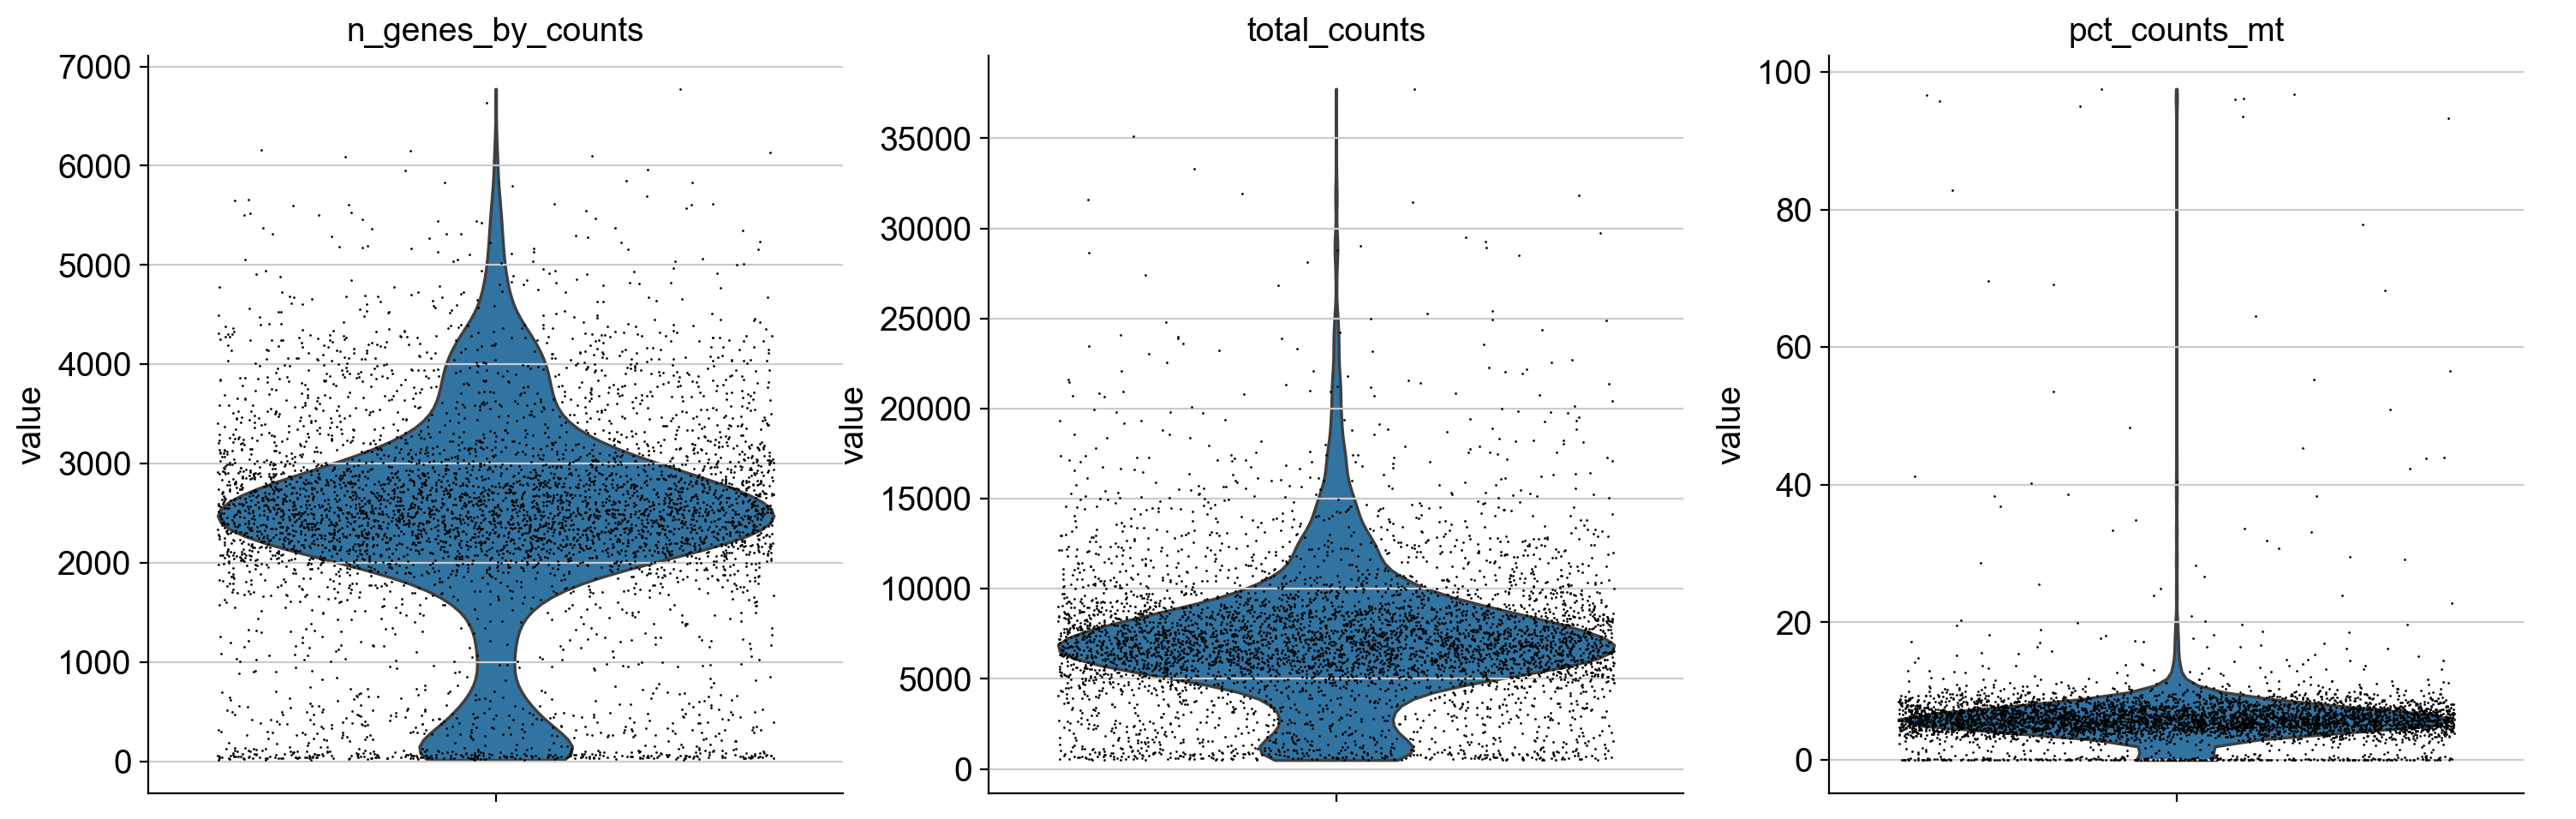

In [3]:
sc.pl.violin(adata, ["n_genes_by_counts", "total_counts", "pct_counts_mt"], jitter=0.4, multi_panel=True)

#### Filtering (QC)

In [4]:
# Remove empty-ish droplets
sc.pp.filter_cells(adata, min_genes=200) 
# Remove potential doublets
adata = adata[adata.obs.n_genes_by_counts < 6000, :] 
# Remove dying cells
adata = adata[adata.obs.pct_counts_mt < 15, :] 
print(f"Cells after QC: {adata.n_obs}")

Cells after QC: 4754


### Normalisation & Log

In [5]:
adata.layers["counts"] = adata.X.copy() 

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata

C:\Users\laura\AppData\Local\Temp\ipykernel_30668\3962883226.py:1: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata.layers["counts"] = adata.X.copy()


##### Feature Selection (HVGs)

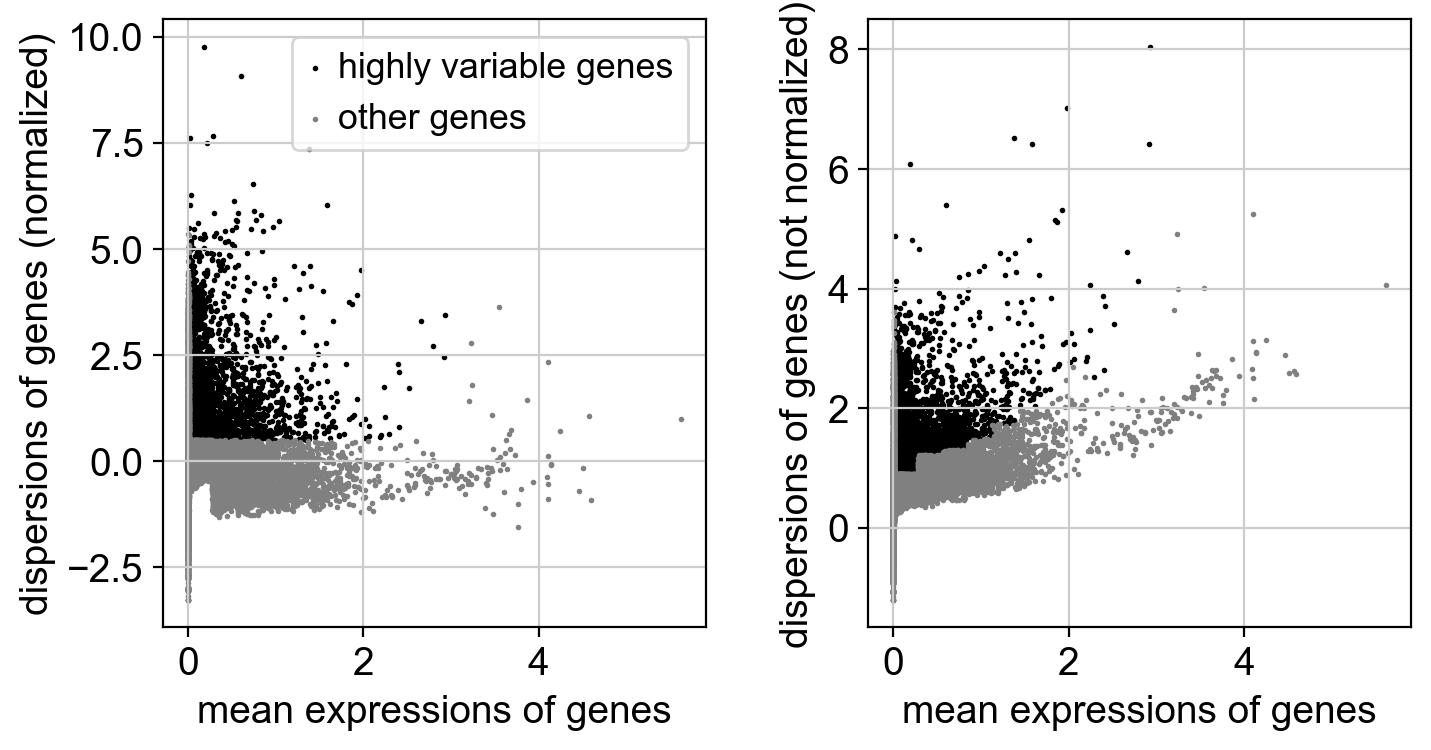

In [6]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pl.highly_variable_genes(adata)

### Dimensionality Reduction (The "Squeeze")

c:\Users\laura\AppData\Local\Programs\Python\Python313\Lib\site-packages\scanpy\preprocessing\_pca\__init__.py:359: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca


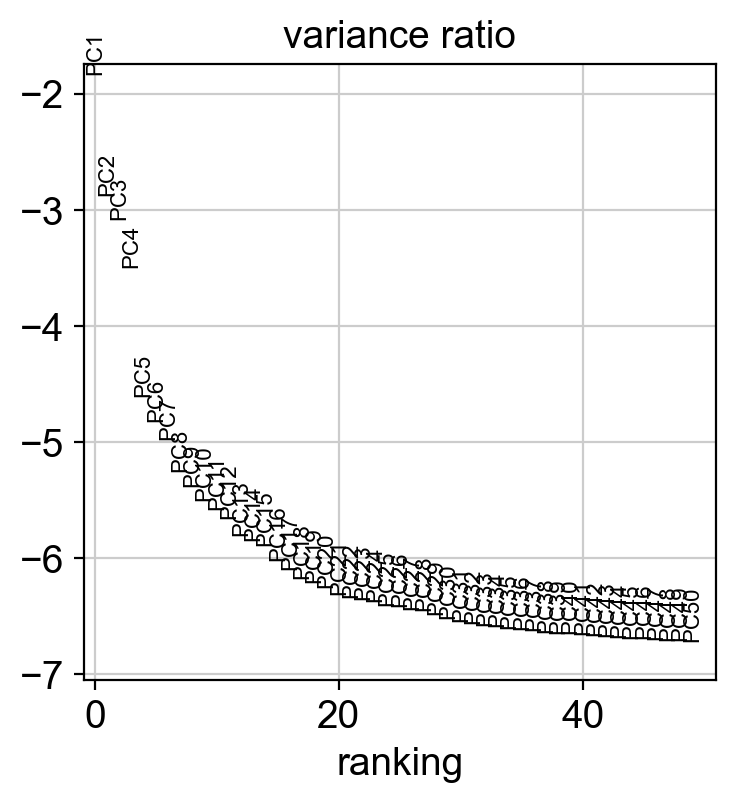

In [7]:
adata = adata[:, adata.var.highly_variable]
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50) # The Elbow Plot
plt.show()

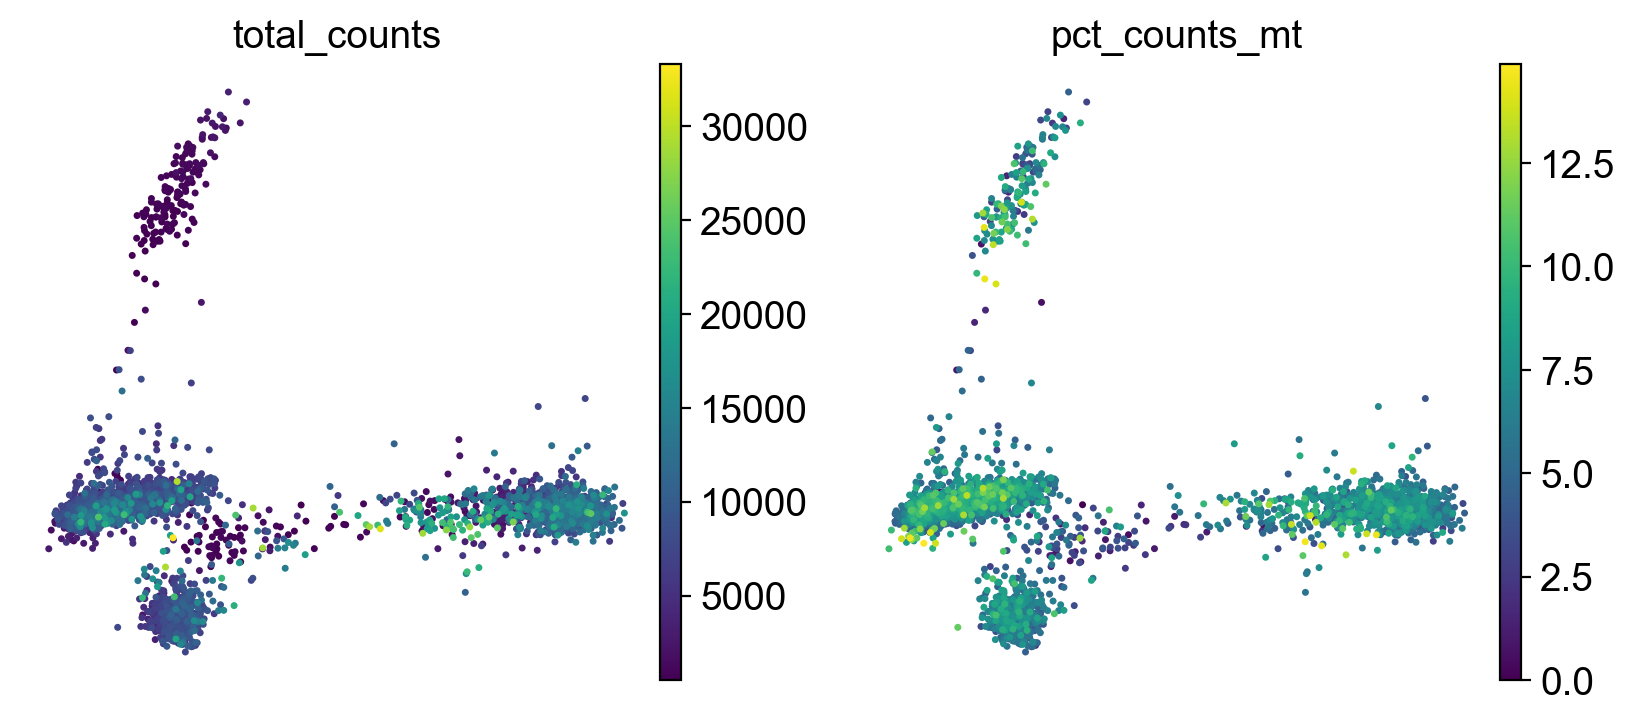

In [8]:
sc.pl.pca(adata, color=['total_counts', 'pct_counts_mt'], cmap='viridis')
plt.show()

### UMAP

c:\Users\laura\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


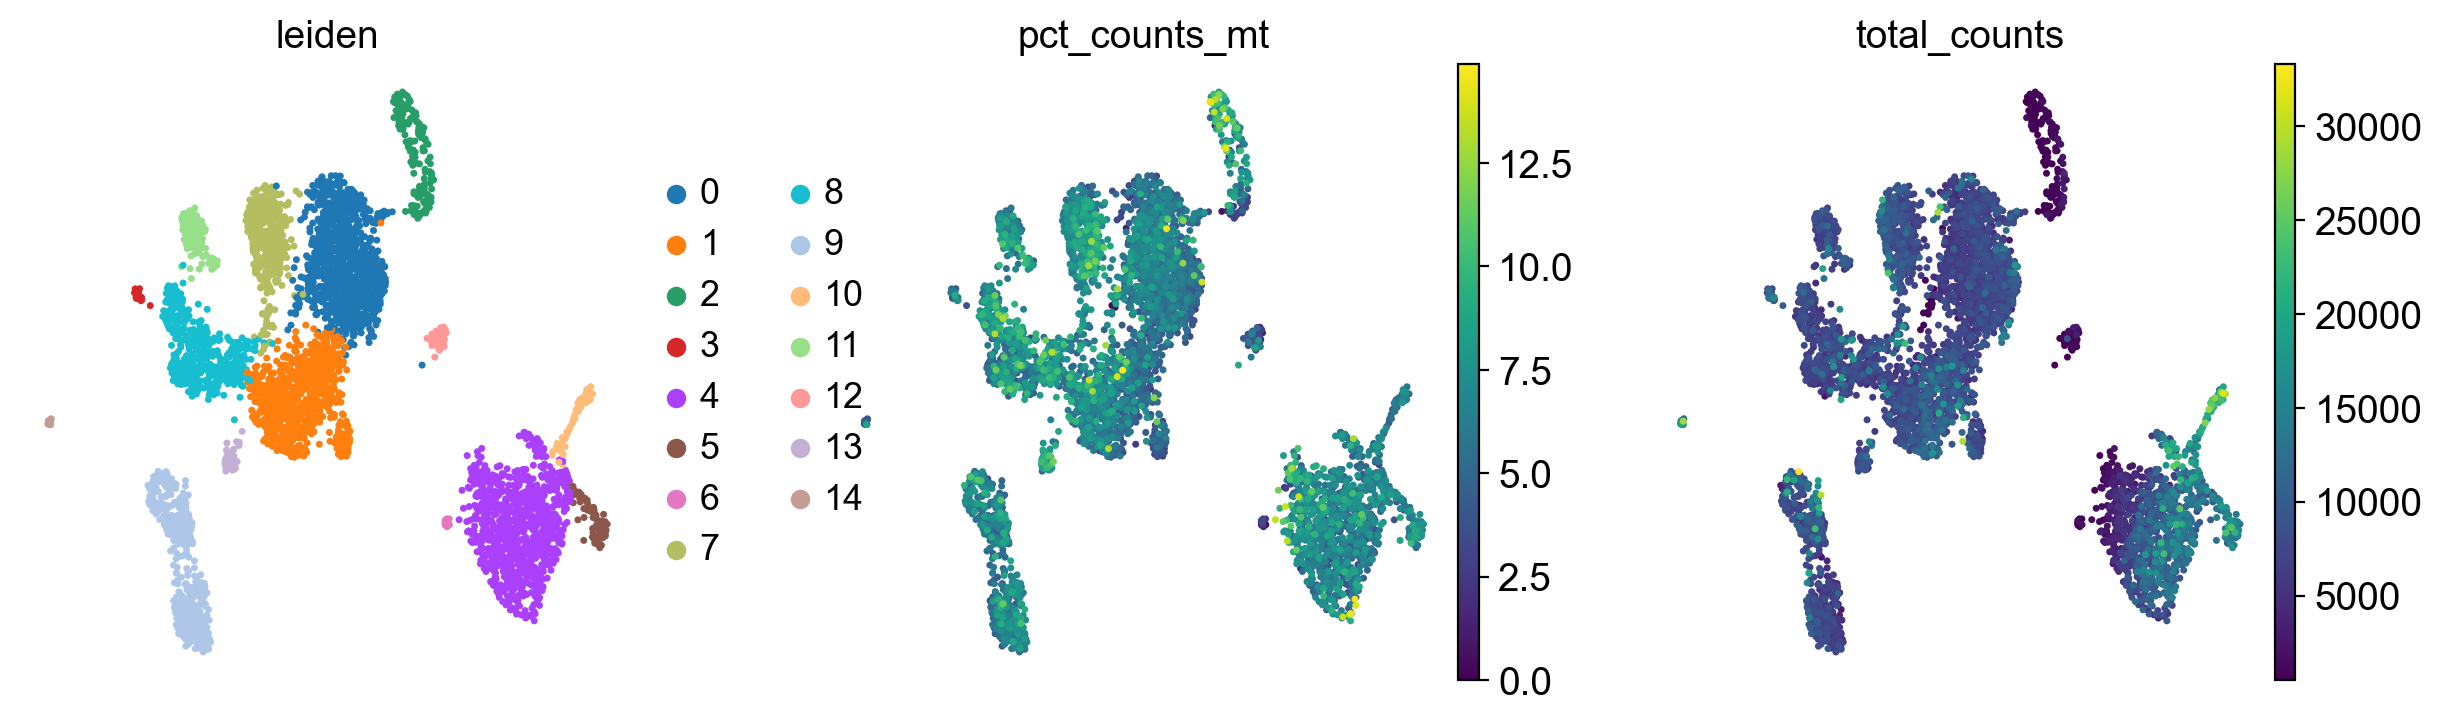

In [9]:
# n_pcs=30 is a safe bet based on your plot
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
# 2. Find clusters (Community detection)
sc.tl.leiden(adata, resolution=0.5, flavor="igraph", n_iterations=2)
# 3. Run UMAP
sc.tl.umap(adata)
sc.pl.umap(adata, color=['leiden', 'pct_counts_mt', 'total_counts'])
plt.show()


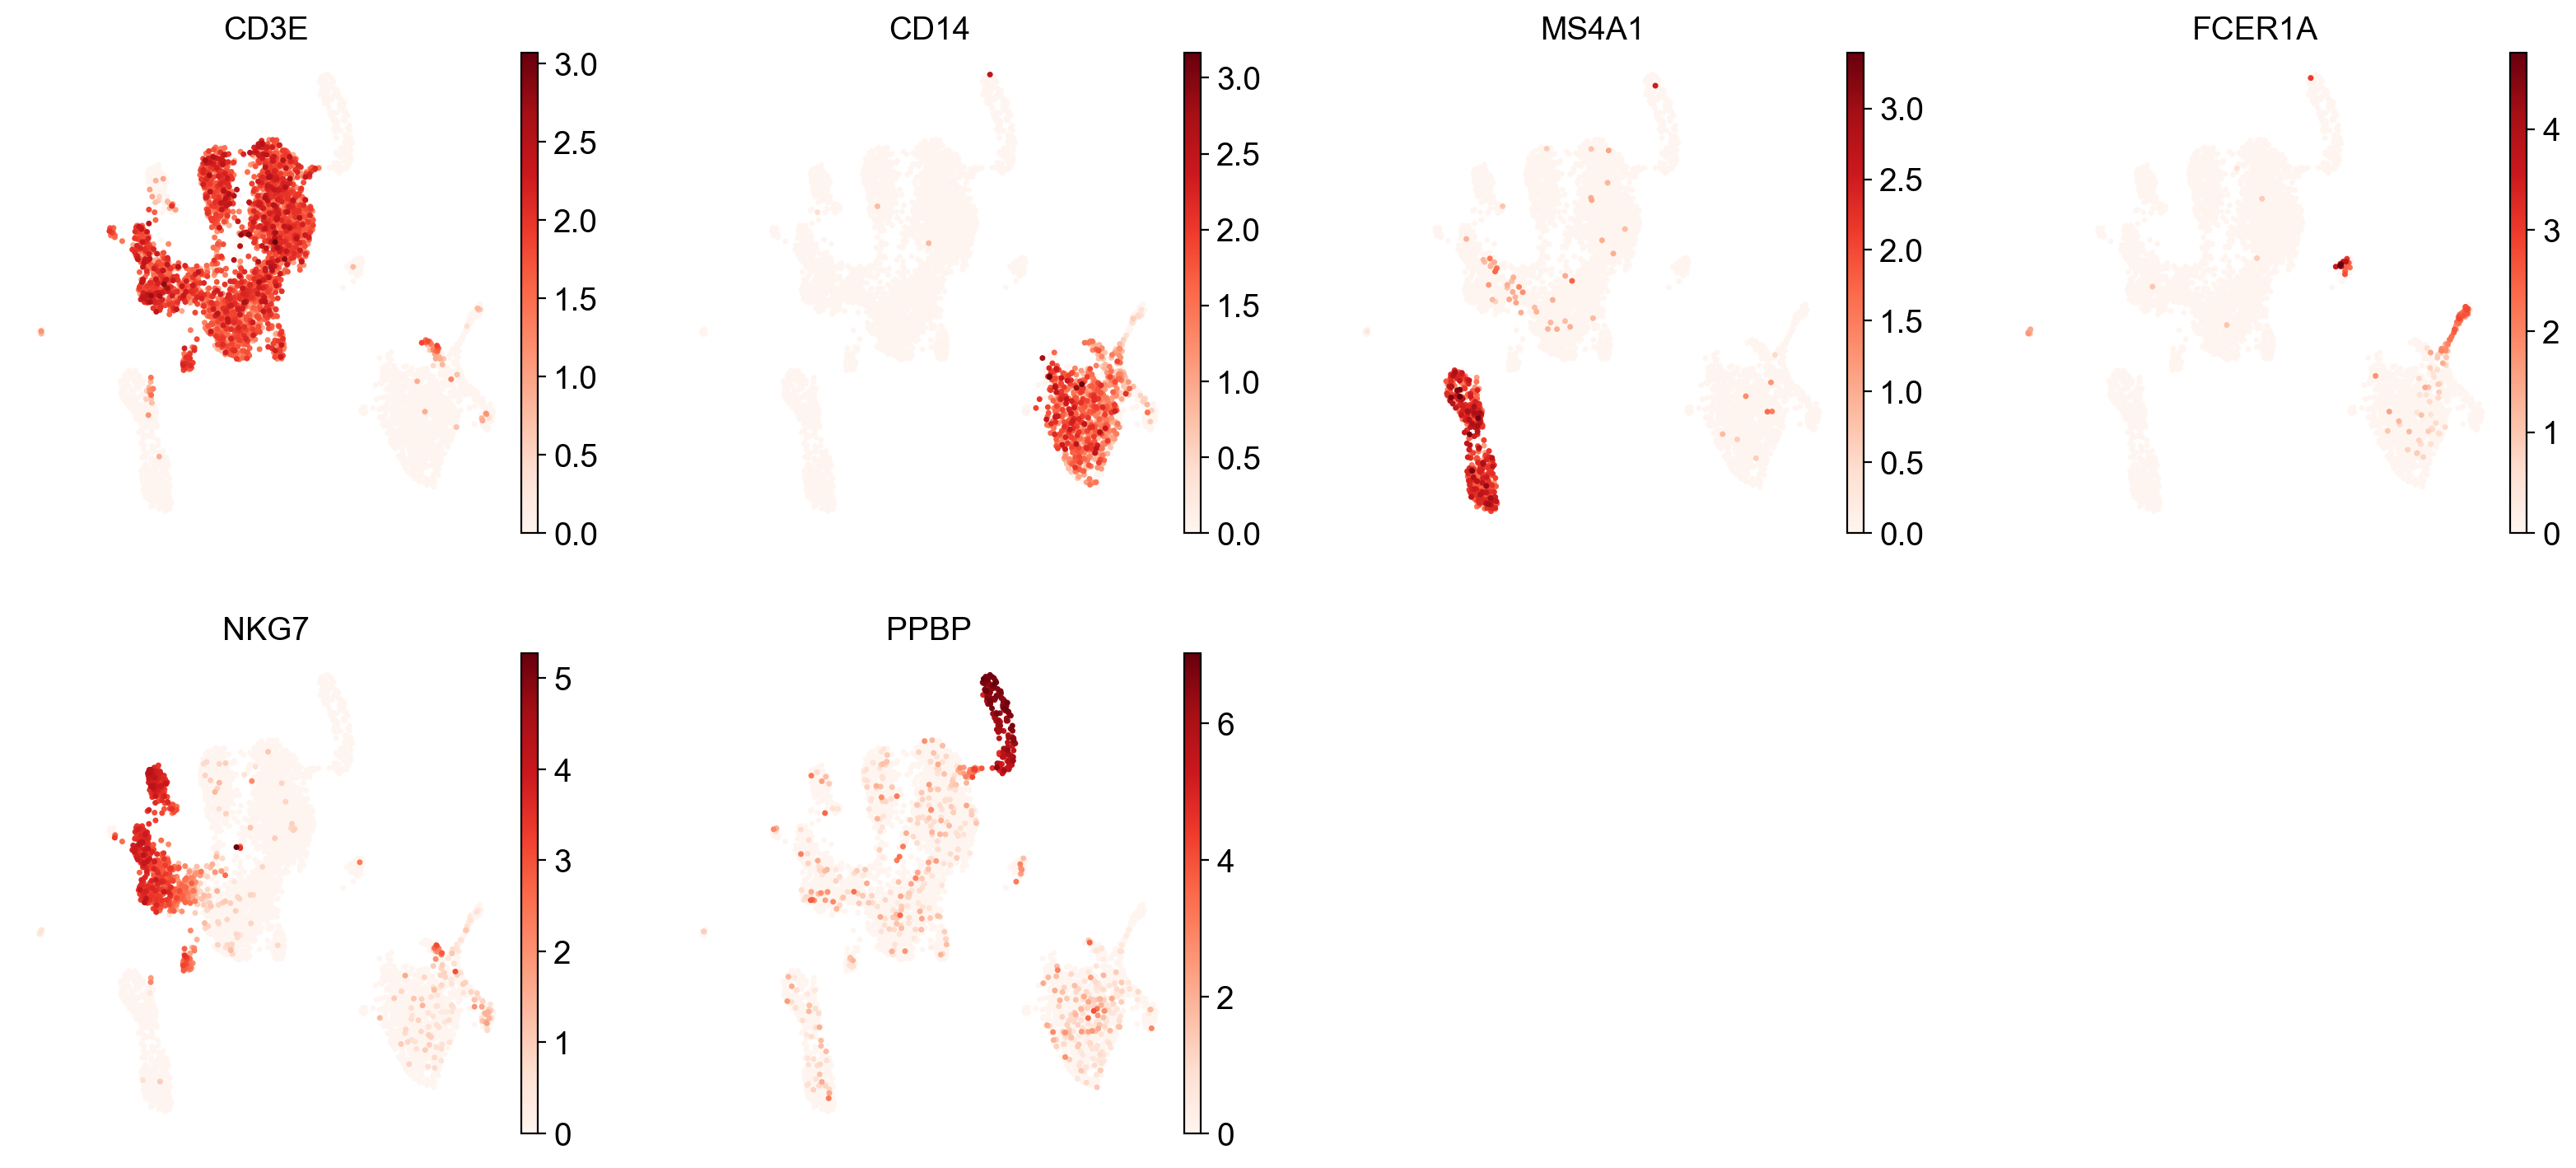

In [10]:
# Canonical markers for PBMCs
# CD3E = T-cells, CD14 = Monocytes, MS4A1 = B-cells, FCER1A = Dendritic Cells
# NKG7 = NK cells, PPBP = Platelets
markers = ['CD3E', 'CD14', 'MS4A1', 'FCER1A', 'NKG7', 'PPBP']

sc.pl.umap(adata, color=markers, cmap='Reds', use_raw=True)

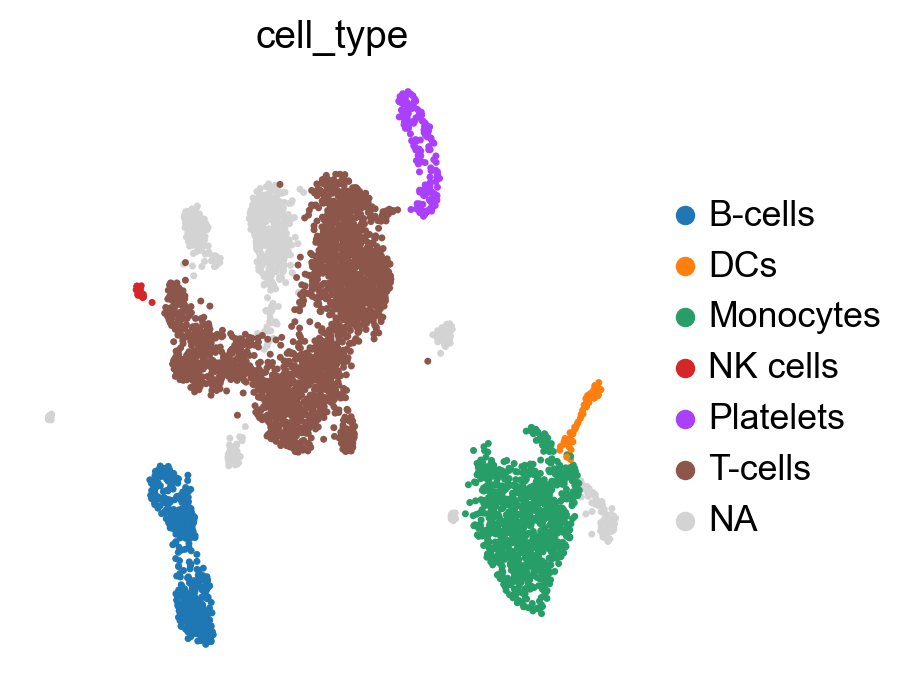

In [12]:
cluster_to_type = {
    "0": "T-cells",
    "1": "T-cells",
    "2": "Platelets",    # Because of PPBP
    "3": "NK cells",     # Because of NKG7
    "4": "Monocytes", 
    "8": "T-cells",   # Because of CD14
    "9": "B-cells",      # Because of MS4A1
    "10": "DCs",
}

adata.obs["cell_type"] = adata.obs["leiden"].astype(str).map(cluster_to_type)
sc.pl.umap(adata, color="cell_type", legend_loc="right margin")

In [15]:
# 1. Run the math first
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')

# 2. Now you can look at the results without the KeyError
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names

# This part prints the top 10 genes per cluster to your screen
import pandas as pd
markers_df = pd.DataFrame(
    {group: result['names'][group][:10] for group in groups}
)
print(markers_df)

         0         1       2         3       4        5         6          7  \
0    RPS3A      EML4   TUBB1      HBA1  S100A9     LST1     NAMPT       CD8B   
1    RPL32      RORA  TMSB4X      HBA2  S100A8    COTL1     NEAT1      NELL2   
2    RPL30    INPP4B   GNG11       HBB    CTSS   TCF7L2    ZFAND3  LINC02446   
3     LEF1      CD69    PPBP  SLC25A37     LYZ   LRRC25     FOXO3      PDE3B   
4    RPL21     SYNE2    NRGN  SLC25A39    VCAN     AIF1      PTEN     THEMIS   
5    RPS13      IL32   H3F3A      GYPC    FCN1    IFI30  ARHGAP26     TGFBR2   
6     RPL9      IL7R   GP1BB       UBB   NEAT1     WARS     CSF3R       LEF1   
7  RAPGEF6    TTC39C     PF4      YBX3  PLXDC2   FCGR3A    JMJD1C       RPS6   
8    RPL11    CDC14A  CAVIN2     FBXO7   CSF3R  S100A11  SLC25A37      APBA2   
9    RPS14  ARHGAP15    OAZ1      SNCA  TYROBP   IFITM3      LCP1      RPS12   

       8          9        10     11      12       13          14  
0   NKG7      BANK1      CST3   GNLY    GAB2    KLR

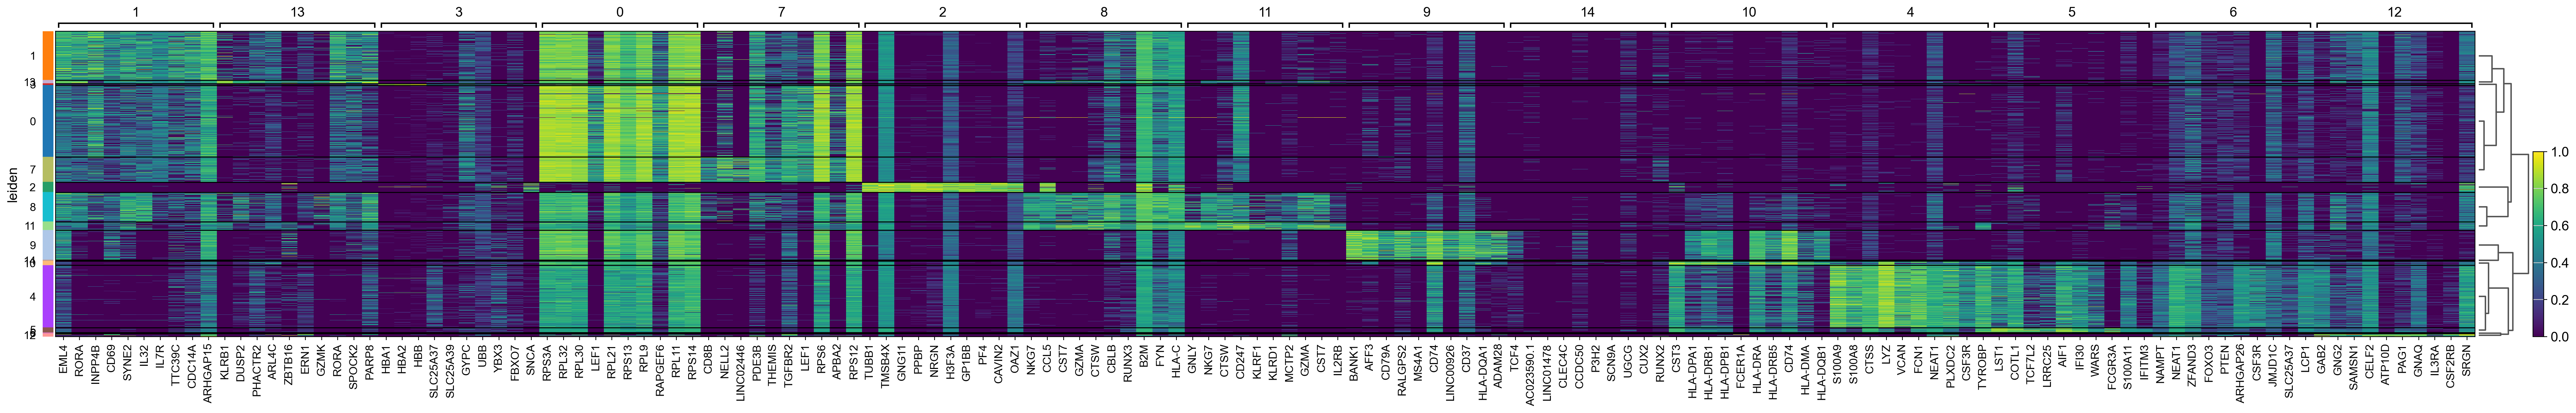

In [16]:
sc.pl.rank_genes_groups_heatmap(
    adata, 
    n_genes=10, 
    groupby="leiden", 
    show_gene_labels=True, 
    standard_scale="var", 
    cmap="viridis"
)